In [ ]:
import pandas as pd
dt = pd.read_csv('28.csv')

dt.head()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235","62,937",Q1,168,47,119,3452,15499,80,126.34,73.45,United States,Northern America,Wiley-Blackwell,1950-2020,Hematology (Q1); Oncology (Q1)
1,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601","40,949",Q1,143,10,9,1292,492,9,50.00,129.20,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2020,Epidemiology (Q1); Health Information Manageme...
2,3,20315,Nature Reviews Molecular Cell Biology,journal,"14710072, 14710080","37,461",Q1,431,115,338,8439,10844,167,32.83,73.38,United Kingdom,Western Europe,Nature Publishing Group,2000-2020,Cell Biology (Q1); Molecular Biology (Q1)
3,4,29431,Quarterly Journal of Economics,journal,"00335533, 15314650","34,573",Q1,259,40,110,2733,1945,109,16.00,68.33,United Kingdom,Western Europe,Oxford University Press,1886-2020,Economics and Econometrics (Q1)
4,5,21100812243,Nature Reviews Materials,journal,20588437,"32,011",Q1,108,92,264,10632,11188,138,32.15,115.57,United Kingdom,Western Europe,Nature Publishing Group,2016-2020,"Biomaterials (Q1); Electronic, Optical and Mag..."


In [ ]:
dt.isnull()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24973,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24974,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24975,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24976,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
dt.isnull().sum()

,0
Rank,0
Sourceid,0
Title,0
Type,0
Issn,0
SJR,0
SJR Best Quartile,0
H index,0
Total Docs. (2020),0
Total Docs. (3years),0


In [ ]:
import numpy as np

def clean_dataset(dt):
    assert isinstance(dt, pd.DataFrame), "dt needs to be a pd.DataFrame"
    dt.dropna(inplace=True)
    indices_to_keep = ~dt.isin([np.nan, np.inf, -np.inf]).any(1)
    return dt[indices_to_keep].astype(np.float64)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [ ]:
#attribut selection
X = dt.iloc[:,[7, 8, 9, 10, 11, 12, 13, 14]].values
y = dt.iloc[:,6].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=10)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
Adanb = AdaBoostClassifier(estimator=nb, n_estimators=1000,
                               random_state=0)

Adanb.fit(X_train, y_train)
Adanb_preds = Adanb.predict(X_test)

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()), ('model', Adanb)])
result = cross_val_score(pipe, X, y, cv=cv)

In [ ]:
print(result)

[0.46877502 0.46196958 0.46597278 0.42153723 0.45316253 0.44795837
 0.46757406 0.4623699  0.45374449 0.44813777]


In [ ]:
result.mean()

np.float64(0.4551201714274904)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, Adanb_preds)

array([[ 845,  645,  560,  224],
       [ 107,  397,  951,  468],
       [  20,   91,  734,  904],
       [  16,   21,  106, 1405]])

In [ ]:
from sklearn.metrics import classification_report
classification_report(y_test, Adanb_preds)

'              precision    recall  f1-score   support\n\n          Q1       0.86      0.37      0.52      2274\n          Q2       0.34      0.21      0.26      1923\n          Q3       0.31      0.42      0.36      1749\n          Q4       0.47      0.91      0.62      1548\n\n    accuracy                           0.45      7494\n   macro avg       0.49      0.48      0.44      7494\nweighted avg       0.52      0.45      0.43      7494\n'

In [ ]:
report = classification_report(y_test, Adanb_preds, output_dict=True)
print("Accuracy:",metrics.accuracy_score(y_test, Adanb_preds))

Accuracy: 0.4511609287429944


In [ ]:
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']

print(precision)
print(recall)

0.49491720015249263
0.47633282185304016


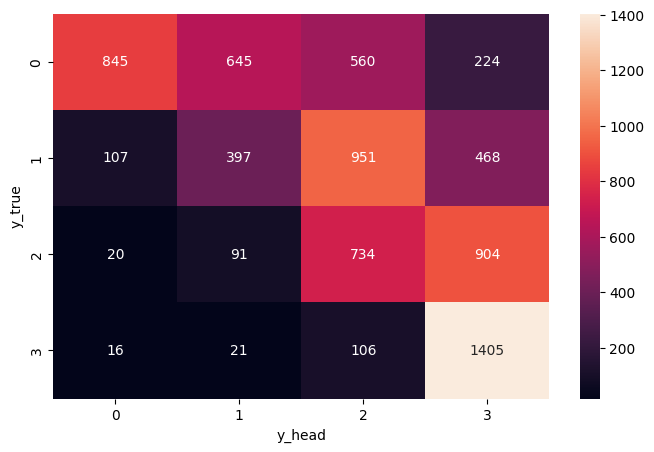

In [ ]:
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, Adanb_preds), annot=True, fmt=".0f", ax=ax)
plt.xlabel("y_head")
plt.ylabel("y_true")
plt.show()

In [ ]:
!pip install yellowbrick

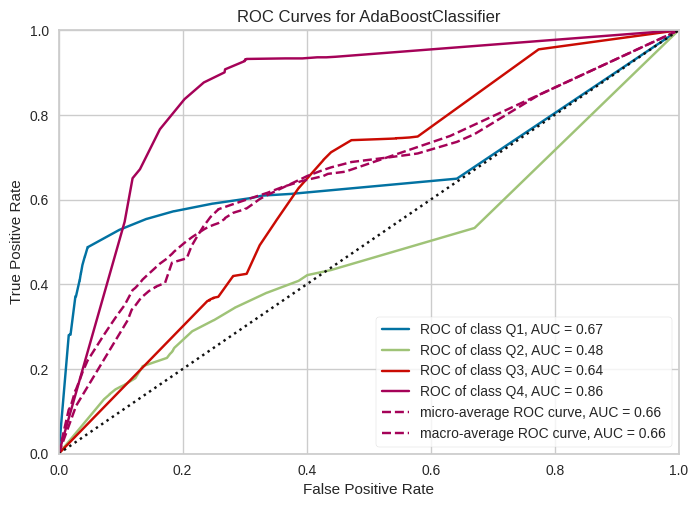

<Figure size 800x550 with 0 Axes>

In [ ]:
from yellowbrick.classifier.rocauc import roc_auc
roc_auc(Adanb, X_train, y_train, X_test=X_test, y_test=y_test)
plt.savefig('roc_auc.png')